In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import string
import re
import nltk
nltk.download('punkt')
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
from nltk.probability import FreqDist
import pymorphy3

In [3]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

In [7]:
with open('2021.txt', 'r') as file:
    data = file.read()

In [9]:
stop_words = stopwords.words('russian')
morph = pymorphy3.MorphAnalyzer()

In [11]:
def tokenize_text(raw_text: str):
    """Функция для токенизации текста
    :param raw_text: исходная текстовая строка
    """
    # Разбиение на сслова при помощи пробела
    words = raw_text.split()
    # Подготовка регулярного выражения для фильтрации символов
    re_punc = re.compile('[%s]' % re.escape(string.punctuation))
    # Удаление знаков препинания
    stripped = [re_punc.sub('', w) for w in words]
    # Приведение всех слов к нижнему регистру
    words_lower = [w.lower() for w in stripped]
    # Удаление оставшихся токенов, которые не являются буквами
    words_alpha = [word for word in words_lower if word.isalpha()]
    # Удаление стоп-слов    
    words_stop = [w for w in words_alpha if not w in stop_words]
    # Лемматизация    
    tokens = [morph.parse(token)[0].normal_form for token in words_stop]
    # Удалим короткие токены
    tokens = [word for word in tokens if len(word) > 2]
      
    return tokens

In [13]:
tokenized = tokenize_text(data)

In [17]:
all_words = FreqDist(tokenized)

In [19]:
print("Наиболлее популярные слова: ", all_words.most_common(100))
print("\nОбщее количество уникальных слов: ", len(all_words.keys()))

Наиболлее популярные слова:  [('брикс', 328), ('страна', 219), ('встреча', 96), ('сотрудничество', 85), ('область', 57), ('также', 55), ('международный', 52), ('группа', 52), ('развитие', 52), ('безопасность', 45), ('министр', 45), ('рабочий', 43), ('заседание', 43), ('вопрос', 42), ('рамка', 41), ('приветствовать', 41), ('год', 40), ('оон', 40), ('технология', 39), ('цель', 36), ('сфера', 36), ('пандемия', 30), ('цифровой', 30), ('использование', 30), ('август', 30), ('система', 29), ('июль', 29), ('наш', 28), ('укрепление', 27), ('число', 27), ('подтверждать', 26), ('форум', 26), ('обеспечение', 24), ('глобальный', 23), ('борьба', 23), ('право', 22), ('роль', 22), ('работа', 22), ('совместный', 22), ('совет', 22), ('май', 22), ('обмен', 21), ('признать', 21), ('связь', 21), ('подчёркивать', 21), ('приверженность', 20), ('мир', 20), ('важность', 20), ('многосторонний', 20), ('терроризм', 20), ('государство', 19), ('реализация', 19), ('экономический', 19), ('итог', 19), ('включая', 19)

C:\Temp\ipykernel_13144\1563493910.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


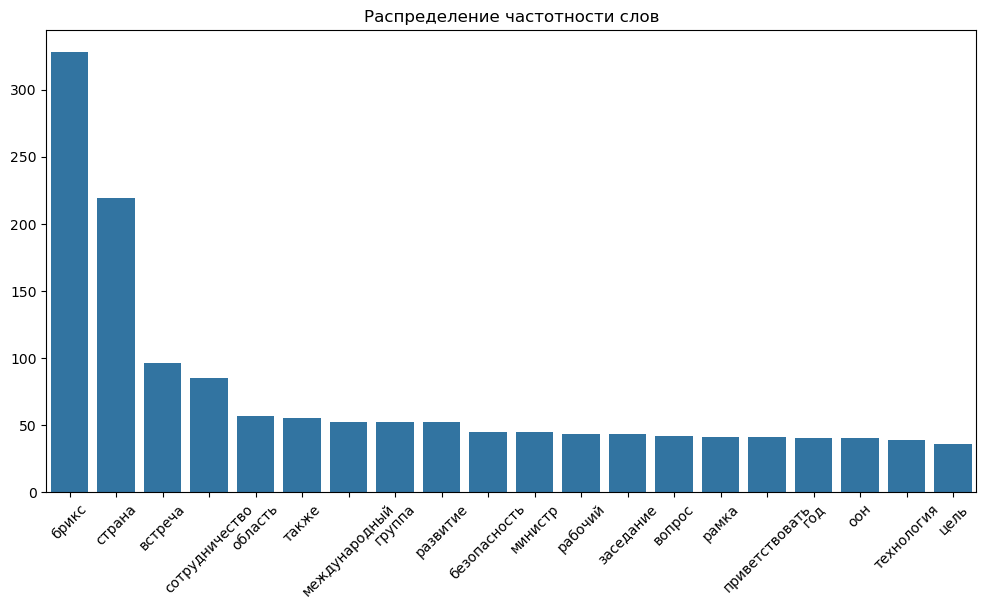

In [21]:
count, words = [], []
for w in all_words.most_common(20):
    words.append(w[0])
    count.append(w[1])
fig,ax = plt.subplots(figsize = (12,6))
ax = sns.barplot(x=words,y=count)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.set_title ('Распределение частотности слов')
plt.show()

In [23]:
stop_words_ex = ['год','наш', 'который', 'также']
def stop_words_extra(text):
    return [w for w in text if not w in stop_words_ex]

In [25]:
tokens = stop_words_extra(tokenized)

C:\Temp\ipykernel_13144\3051857113.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


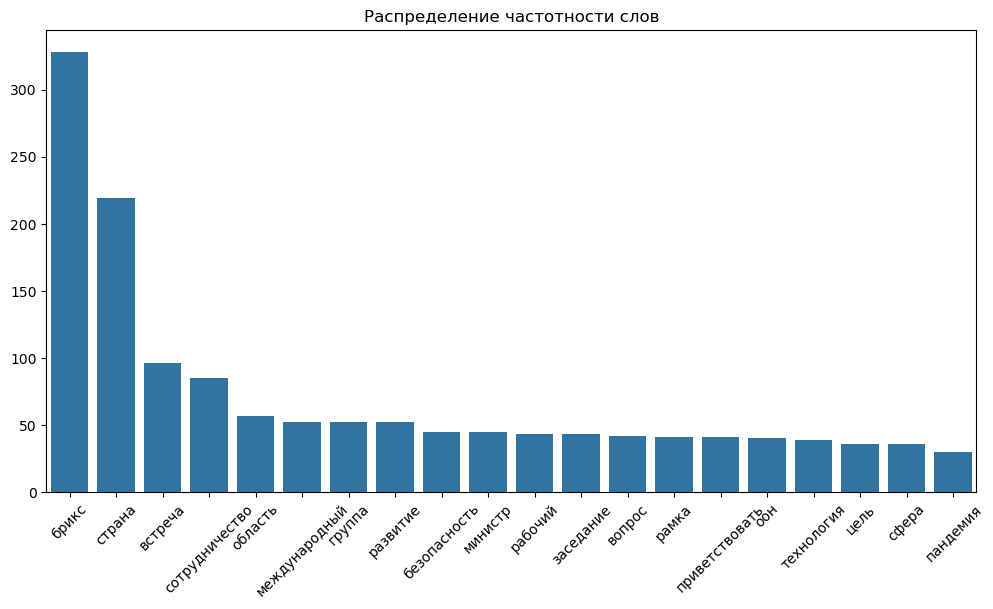

In [27]:
all_words = FreqDist(tokens)
count, words = [], []
for w in all_words.most_common(20):
    words.append(w[0])
    count.append(w[1])
fig,ax = plt.subplots(figsize = (12,6))
ax = sns.barplot(x=words,y=count)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.set_title ('Распределение частотности слов')
plt.show()

In [29]:
textt = ','.join(w for w in tokens)

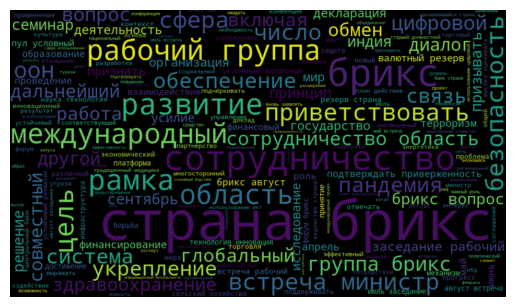

In [31]:
wordcloud = WordCloud(width=950,height=550).generate(textt)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [33]:
# Приводим текст в векторное представление
tfidf_vect = TfidfVectorizer(max_df=1.0, min_df=2, stop_words=None)
doc_term_matrix = tfidf_vect.fit_transform(tokens)

### Латентное размещение Дерихле

In [36]:
LDA = LatentDirichletAllocation(n_components=2, random_state=42)
LDA.fit(doc_term_matrix)

LatentDirichletAllocation(n_components=2, random_state=42)

In [37]:
for i,topic in enumerate(LDA.components_):
    print(f'Top 10 words for topic #{i}:')
    print([tfidf_vect.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print('\n')

Top 10 words for topic #0:
['сфера', 'цель', 'технология', 'приветствовать', 'вопрос', 'безопасность', 'развитие', 'международный', 'сотрудничество', 'брикс']


Top 10 words for topic #1:
['пандемия', 'оон', 'рамка', 'рабочий', 'заседание', 'министр', 'группа', 'область', 'встреча', 'страна']




In [38]:
LDA = LatentDirichletAllocation(n_components=3, random_state=42)
LDA.fit(doc_term_matrix)
for i,topic in enumerate(LDA.components_):
    print(f'Top 10 words for topic #{i}:')
    print([tfidf_vect.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print('\n')

Top 10 words for topic #0:
['важность', 'связь', 'роль', 'работа', 'глобальный', 'обеспечение', 'июль', 'система', 'использование', 'международный']


Top 10 words for topic #1:
['подтверждать', 'укрепление', 'цифровой', 'пандемия', 'август', 'оон', 'рамка', 'заседание', 'министр', 'область']


Top 10 words for topic #2:
['приветствовать', 'вопрос', 'рабочий', 'безопасность', 'группа', 'развитие', 'сотрудничество', 'встреча', 'страна', 'брикс']




Вывод: тематика декларации 2021 г. посвящена общим вопросам международного сотрудничества и пандемии КОВИД19